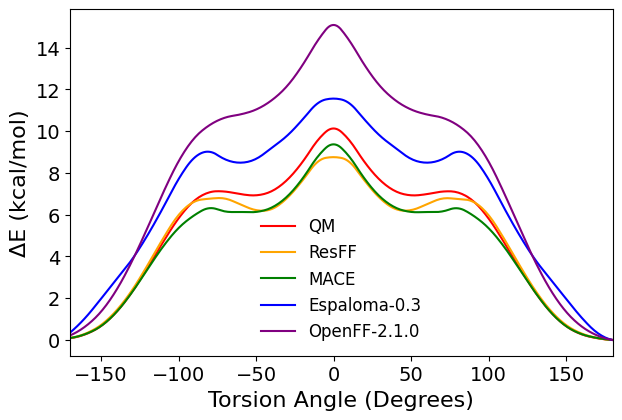

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from scipy.interpolate import make_interp_spline
import matplotlib.ticker as ticker

name = 'Cn1ccnc1c2ccccn2'
path = f"./torsionscan/example_molecule/{name}.csv"
data1 = pd.read_csv(path)


x1 = data1['torsion']
y1 = data1['wb97m']
y2 = data1['resff']
y3 = data1['mace']
y4 = data1['esp']
y5 = data1['openff'] 


x_smooth = np.linspace(x1.min(), x1.max(), 300)  

def smooth_curve(x, y):
    spline = make_interp_spline(x, y, k=2)  
    return spline(x_smooth)

y1_smooth = smooth_curve(x1, y1)
y2_smooth = smooth_curve(x1, y2)
y3_smooth = smooth_curve(x1, y3)
y4_smooth = smooth_curve(x1, y4)
y5_smooth = smooth_curve(x1, y5)

plt.figure(figsize=(7, 4.5))


plt.plot(x_smooth, y1_smooth, linestyle='-', color='red', label='QM')
plt.plot(x_smooth, y2_smooth, linestyle='-', color='orange', label='ResFF')
plt.plot(x_smooth, y3_smooth, linestyle='-', color='green', label='MACE')
plt.plot(x_smooth, y4_smooth, linestyle='-', color='b', label='Espaloma-0.3')
plt.plot(x_smooth, y5_smooth, linestyle='-', color='purple', label='OpenFF-2.1.0')


plt.xlabel('Torsion Angle (Degrees)', fontsize=16)
plt.ylabel('ΔE (kcal/mol)', fontsize=16)
plt.xlim(-170, 180)
plt.tick_params(axis='both', labelsize=14)

plt.legend(fontsize=12, frameon=False) 
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(2))
#plt.savefig(f"./torsionscan/example_molecule/{name}.png", dpi=600)  

plt.show()

